In [154]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings 

In [155]:
df=pd.read_csv('insurance.csv')
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [156]:
df.shape

(1338, 7)

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [158]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [159]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [160]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

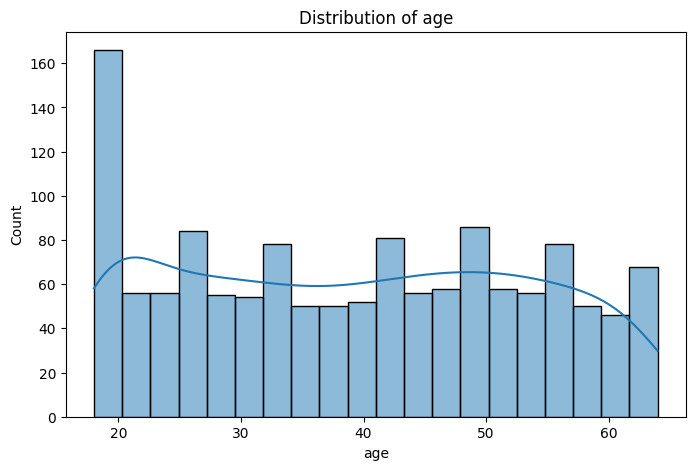

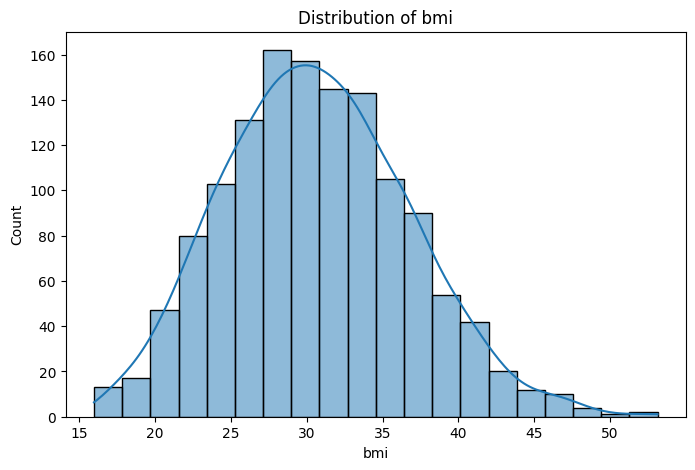

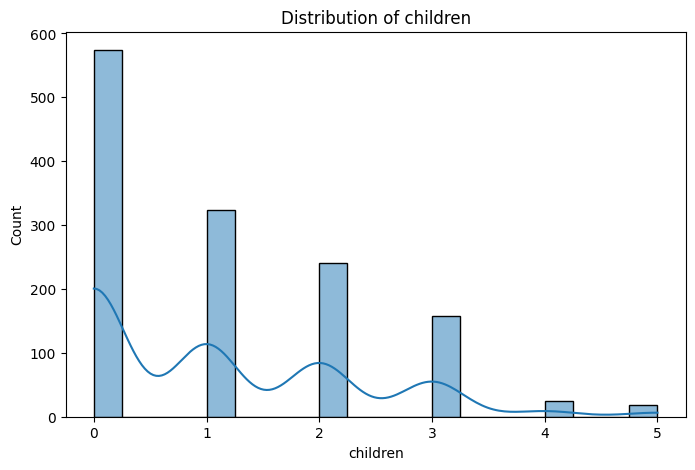

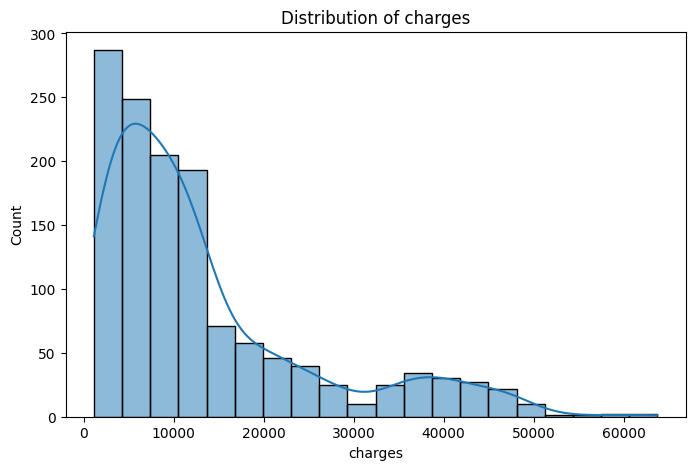

In [161]:
numeric_columns=['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col],kde=True,bins=20)
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: xlabel='children', ylabel='count'>

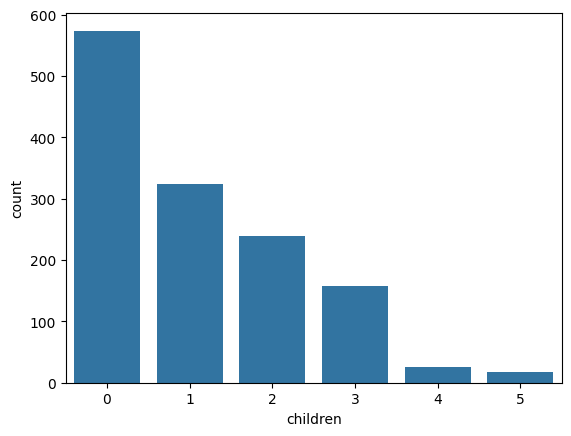

In [162]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

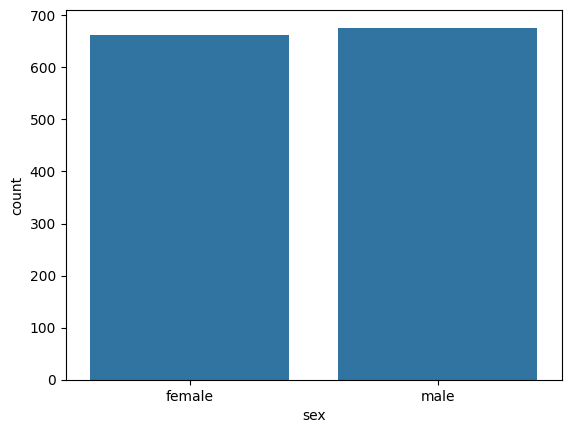

In [163]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

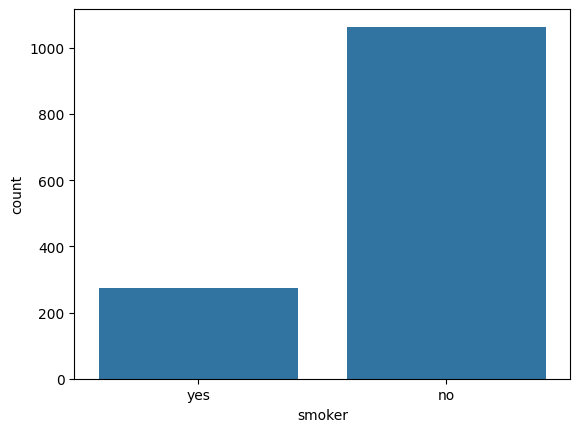

In [164]:
sns.countplot(x=df['smoker'])

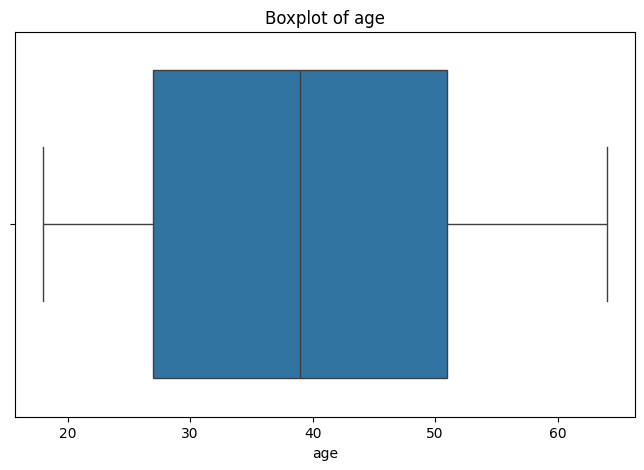

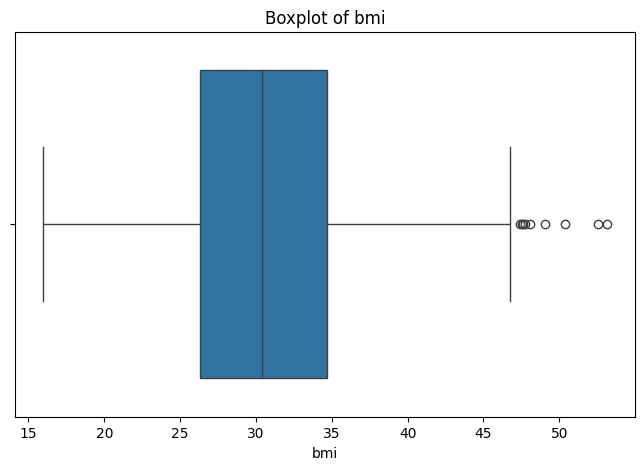

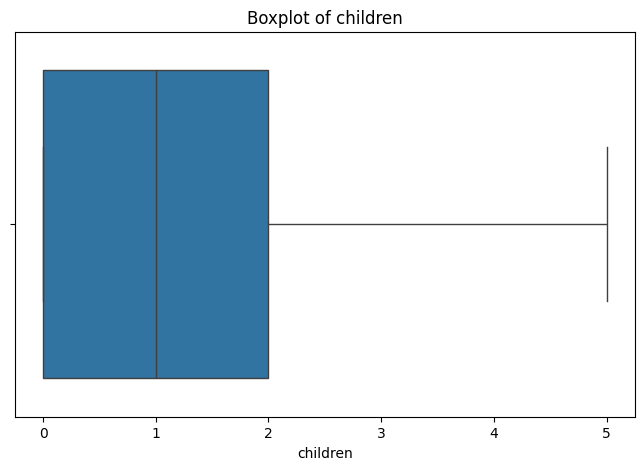

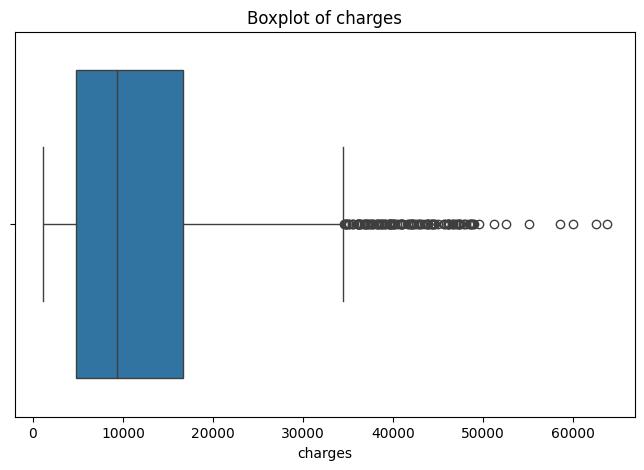

In [165]:
for col in numeric_columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')


<Axes: >

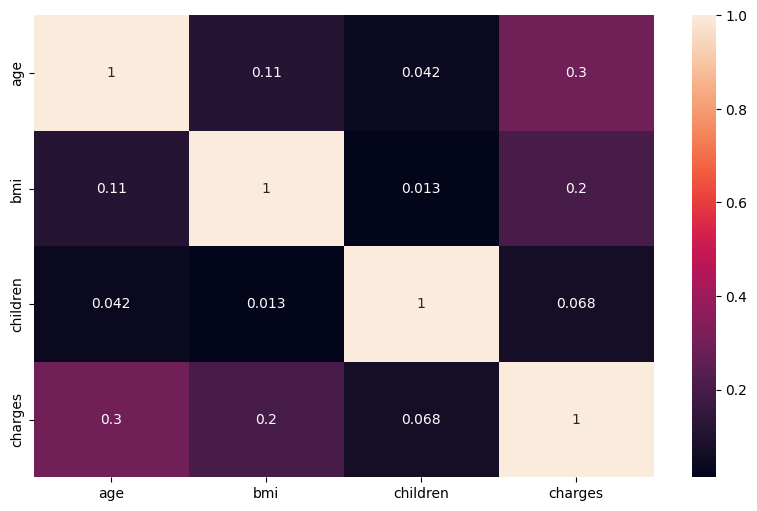

In [166]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

data cleaning and preprocessing 

In [167]:
df_cleaned=df.copy()    
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [168]:
df_cleaned.shape

(1338, 7)

In [169]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [170]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [171]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [172]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [173]:
df_cleaned['smoker'].value_counts() 

smoker
no     1063
yes     274
Name: count, dtype: int64

In [174]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'no':0,'yes':1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [175]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
                         },inplace=True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [176]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [177]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [178]:
df_cleaned=df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


feature engineering and extraction 

In [179]:
df_cleaned['bmi_category']=pd.cut(df_cleaned['bmi'],
                                  bins=[0,18.5,24.9,29.9,float('inf')],
                                  labels=['underweight','normal','overweight','obese'])
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight


In [180]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)   
df_cleaned=df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [181]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [186]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scalar=StandardScaler()
df_cleaned[cols]=scalar.fit_transform(df_cleaned[cols])
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [191]:
from scipy.stats import pearsonr
selected_features=['age','bmi','children','is_female','is_smoker','region_northwest','region_southeast','region_southwest',
                   'bmi_category_normal','bmi_category_overweight','bmi_category_obese']
correlations={
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0] 
    for feature in selected_features
}
correlations_df=pd.DataFrame(list(correlations.items()), columns=['Feature','Pearson Correlation'])
correlations_df.sort_values(by='Pearson Correlation', ascending=False)



,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_normal,-0.104042


In [196]:
cat_features=['is_female','is_smoker','region_northwest','region_southeast','region_southwest',
               'bmi_category_normal','bmi_category_overweight','bmi_category_obese']

In [202]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Discretize charges into 4 quantiles
df_cleaned['charges_category'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

chi2_result = {}

for feature in cat_features:
    contingency_table = pd.crosstab(df_cleaned[feature], df_cleaned['charges_category'])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    
    decision = 'Reject Null Hypothesis' if p_value < alpha else 'Fail to Reject Null Hypothesis'
    
    chi2_result[feature] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_value,
        'Decision': decision
    }

# Display results
chi2_result

{'is_female': {'chi2_statistic': np.float64(10.258784131896034),
  'p_value': np.float64(0.016489740254825688),
  'Decision': 'Reject Null Hypothesis'},
 'is_smoker': {'chi2_statistic': np.float64(848.2191784691495),
  'p_value': np.float64(1.5074776554531109e-183),
  'Decision': 'Reject Null Hypothesis'},
 'region_northwest': {'chi2_statistic': np.float64(1.1342403613235656),
  'p_value': np.float64(0.76881540917986),
  'Decision': 'Fail to Reject Null Hypothesis'},
 'region_southeast': {'chi2_statistic': np.float64(15.998167448977355),
  'p_value': np.float64(0.0011349657141180658),
  'Decision': 'Reject Null Hypothesis'},
 'region_southwest': {'chi2_statistic': np.float64(5.091893034250699),
  'p_value': np.float64(0.16519063312163632),
  'Decision': 'Fail to Reject Null Hypothesis'},
 'bmi_category_normal': {'chi2_statistic': np.float64(3.7080882993067794),
  'p_value': np.float64(0.29475953089283036),
  'Decision': 'Fail to Reject Null Hypothesis'},
 'bmi_category_overweight': {'c